### Foreground Extraction using GrabCut Algorithm

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Grab cut is a technique that is used to extract the foreground of the image by defining a rectangular region outside of which everything is considered background
# Then GrabCut extracts the foreground from the image inside the rectangle

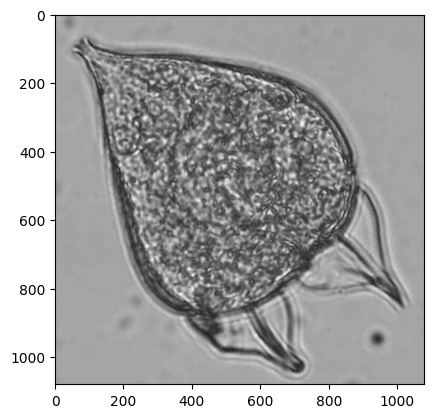

In [2]:
# Loading the image 
img = cv2.imread("/Users/mohammadbilal/Documents/Projects/Practice/python/opencv/Basics/assets/test.jpg")
assert img is not None, "File not found" #Checks if the file exists 
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

In [ ]:
# Defining the rectangle 
h, w = img.shape[:2]
rect = (650, 0, 1300 , 950) # (x, y, width, height)

In [8]:
# creating a mask, bgdModel and fgdModel
mask = np.zeros(img.shape[:2], np.uint8) # it is a mask image which stores the GrabCut Results
# Area Types:
# background, foreground or probable background/foreground
# It is done by the following flags, cv.GC_BGD, cv.GC_FGD, cv.GC_PR_BGD, cv.GC_PR_FGD, or simply pass 0,1,2,3 to image.

bgdModel = np.zeros((1,65), np.float64) # used by the algorithm internally
fgdModel = np.zeros((1,65), np.float64)


In [9]:
# GrabCut with rectangle mode
cv2.grabCut(img, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT) # 5 defines the number of iteration

(array([[0, 0, 0, ..., 3, 3, 3],
        [0, 0, 0, ..., 3, 3, 3],
        [0, 0, 0, ..., 3, 3, 3],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(1080, 1080), dtype=uint8),
 array([[3.78484304e-01, 1.63003853e-01, 1.44656951e-01, 1.25248323e-01,
         1.88606569e-01, 1.64811520e+02, 1.64811520e+02, 1.64811520e+02,
         1.04749536e+02, 1.04749536e+02, 1.04749536e+02, 7.26999792e+01,
         7.26999792e+01, 7.26999792e+01, 1.81934660e+02, 1.81934660e+02,
         1.81934660e+02, 1.40251148e+02, 1.40251148e+02, 1.40251148e+02,
         3.82210126e+00, 3.81210126e+00, 3.81210126e+00, 3.81210126e+00,
         3.82210126e+00, 3.81210126e+00, 3.81210126e+00, 3.81210126e+00,
         3.82210126e+00, 7.91727211e+01, 7.91627211e+01, 7.91627211e+01,
         7.91627211e+01, 7.91727211e+01, 7.91627211e+01, 7.91627211e+01,
         7.91627211e+01, 7.91727211e+01, 1.36626152e+02, 1.36616152e+02,
         1.36616152e+02,

In [ ]:
mask2 = np.where((mask==2)|(mask==0),0,1).astype('uint8') # Pixels with value 0 or 2 (definite/probable background) → 0 (background)
mask2 = mask2[:, :, np.newaxis] # adding the channel axis
result = img*mask2 # Multiplies image by mask (background pixels become black, foreground preserved)

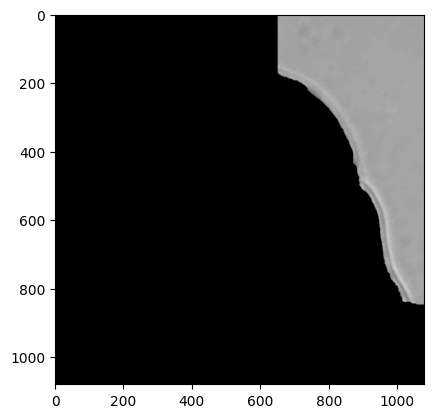

In [7]:
# Displaying the end result
plt.imshow(result)